
</p>
<img src="Otter HPU.png" alt="Otter logo" width="280" align="left" style="margin-right: 15px; border-radius: 8px;">

# Otter Hydraulic System — Condition Monitoring Notebook #3 (Develop System Health KPIs and Indicators)

This is clean final version of notebook which runs a data processing pipeline to create a serie sof useful health status informative flags and stauses from the data sete created in notebook 3
The functions pipeline is located at /piplines/otter_pipeline__labelling_function_defiinitons.py

the notebook also reads in aplot .py file where functions are defined to plot the KPI healh data (seperated in order to keep this notebook clean)

Final clean of data before the next and final notebook 4 to complete unsupervised and supervised learning




| Function | Description |
|:--|:--|
| `add_low_fluid_consumption_label` | Flags sustained periods of low fluid consumption using either hysteresis (“episode”) or a rolling-window stability test, and writes a boolean label. |
| `label_valve_pcv_operations` | Marks time periods as “operation” when valve or PCV flow exceeds a threshold, with persistence, gap-bridging, and summary options. |
| `label_fcv_operation_from_col` | Creates a boolean FCV operation mask from `FCV_Fluid_Usage` using a rate threshold (used by the main pipeline). |
| `add_fcv_operation_simple` | Adds a quick per-sample FCV operation flag based on a simple L/min threshold, plus basic summary statistics. |
| `label_tank_fills` | Detects tank-fill bursts from positive level jumps (with backup period/threshold) and adds an `is_tank_fill` flag. |
| `detect_umbilical_charge_events` | Finds umbilical pressurising events when signals cross low→high thresholds and estimates fluid used from tank level. |
| `apply_umbilical_charge_rate` | Distributes each detected event’s fluid volume evenly across its duration, adding per-row and cumulative volume columns. |
| `process_umbilical_charges` | Convenience wrapper combining detection and volume distribution for umbilical charge events. |
| `label_is_pressurising_from_events` | Converts event timestamps into a boolean time mask (`is_pressurising`) with gap-bridging and persistence logic. |
| `detect_and_label_pressurising` | One-call wrapper: detects pressurising events → optionally spreads volumes → writes `is_pressurising`. |
| `label_high_external_losses` | Labels minutes where `External_Losses` exceed a daily-rate threshold (converted to L/min), with persistence and optional plotting. |
| `add_high_external_losses_label` | Alternative high-loss detector using hysteresis (“episode”) or rolling-mean (“sliding”) to produce `is_losses_high`. |
| `label_high_pressure` | Flags LP/HP high-pressure states relative to thresholds, enforcing a minimum duration and gap-bridging between samples. |
| `label_pressure_low` | Flags LP/HP low-pressure states against defined thresholds. |
| `detect_loss_redundancy` | Detects “no redundancy” periods when any specified pressure channels fall below a defined bar threshold. |
| `detect_low_supply_tank_level` | Flags when supply tank level (L) is below a threshold and can visualize these intervals. |
| `add_pump_states` | Derives HP/LP pump start rates (2 h & 24 h), classifies states (steady/elevated/high), and adds rate, state, and “normal” indicators. |
| `run_labelling_pipeline` | Master function that executes all the above steps in sequence and returns the labeled dataset with step metadata. |



In [1]:
from __future__ import annotations

# Standard library
import gc
import json
import os
import re
import sys
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, Union

# Third-party
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
import shap
from IPython.display import HTML, display
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [ ]:

#Setup Pipeline folder (note pipline and notebooks stored in Github format so one directory back from this notebook)

pipeline_path = os.path.abspath('../pipeline')
if pipeline_path not in sys.path:
    sys.path.append(pipeline_path)

# confiofile contains setppoints/thresholds iitns/threshoilds/
import otter_config as cfg # contains all filepaths and global variables/parameters

#All data handling/processing/features/cleaning functions located here
from otter_pipeline_function_definitions import (run_full_pipeline,clean_dataframe_and_split_valves)

# 2) Import Labeling Pipleine and the Plot functions
from otter_pipeline__labelling_function_definitions import run_labelling_pipeline
from otter_plot_functions import (plot_hpu_data,plot_low_consumption,plot_losses_daily,plot_losses_hourly,plot_last_weeks_with_overlays,plot_external_losses_high,plot_valve_pcv_ops,plot_fcv_usage_vs_operation_line,plot_level_vs_fill_label,plot_pressurising_vs_channels,evaluate_pressure_flags,plot_lp_hp_flags,overlay_external_losses_with_pumps,overlay_losses_with_pump_states,plot_hpu_outputs_with_lp_runs,plot_hp_runs,plot_hp_2h_dropslopes,plot_lpa_dropslopes_with_valves,plot_drop_slopes,plot_pump_states_timeline,)


In [ ]:
# Pipeline 1 to readin all data, process data, clean data and save data for last 7 years, 
df_all_otter = run_full_pipeline(
    parquet_path=r"C:\Users\rosst\OneDrive\Control Integrity\Data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet" ,
    columns_to_remove=cfg.columns_to_remove,
    valve_columns=cfg.valve_columns,
    valve5_volume=cfg.valve5_volume,
    valve2_volume=cfg.valve2_volume,
    valve_hp_volume=cfg.valve_hp_volume,
    pcv_columns=cfg.pcv_columns,
    thresholds=cfg.thresholds,
    pump_events_path=cfg.pump_events_path,
    valve_transition_cols=cfg.valve_transition_cols,
    drop_slope_data_path=cfg.drop_slope_data_path,
    use_smoothed_tank=True,          #
    smoothing_strength=5,          
    combine_sensors="both",
    years_back=7
)




Loaded 3682088 rows × 69 cols (last 7 years: 2017-05-01 → 2024-05-01)
✅ Transition tracking columns created and combined metrics computed.
✅ FCV processing complete: full steps & fluid usage added.
✅ PCV processing complete: steps & fluid usage added.
✅ Tank levels converted to litres for: HPU_SPLY_LEV_L, HPU_SPLY_LEV_B_L, HPU_RET_LEV_L, HPU-RET_LEV_B_L
Dropped 427 duplicate rows from slope_df.


Run the data health status indicator pipleine to derive KPIS 

In [4]:
# Read in pre saved data file after data procesisng steps and run Labelling pipleine on last 7 years

path = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\df_all_otter_clean_post_pipeline_2308_v3.parquet"

# 1) cutoff (last 3 years)
cutoff = pd.Timestamp.today() - pd.DateOffset(years=7)

# 2) find how the index is stored in the parquet
schema = pq.read_schema(path)
pandas_md = json.loads(schema.metadata[b"pandas"])
index_cols = pandas_md["index_columns"]          # e.g. ['__index_level_0__'] or ['timestamp']
index_name = index_cols[0] if index_cols else None

# 3) read only the last 3 years using filter pushdown
df_last7yrs = pd.read_parquet(
    path,
    engine="pyarrow",
    filters=[(index_name, ">=", cutoff)]
)

# ensure the index is datetime and sorted
df_last7yrs = df_last7yrs.set_index(pd.to_datetime(df_last7yrs.index)).sort_index()
print(df_last7yrs.index.min(), "→", df_last7yrs.index.max(), df_last7yrs.shape)


# Run labeling pipeline
labeled_df, metas = run_labelling_pipeline(
    df_last7yrs,
    channel_thresholds=cfg.UMBILICAL_THRESHOLDS,
    pressurising_level_col='HPU_SPLY_LEV_L',
    plot=False,   # keep plots off in pipelines
)



2018-11-08 19:38:00 → 2024-05-01 00:00:00 (2880208, 189)


In [5]:
print(labeled_df.shape)
print(labeled_df.index.dtype)
labeled_df.head()
print(labeled_df.columns.tolist())

(2879903, 211)
datetime64[ns]
['HPU_SPLY_LEV', 'HPU_RET_LEV', 'HPU_LP_A_SPLY', 'HPU_LP_B_SPLY', 'HPU_HP_A_SPLY', 'HPU_HP_B_SPLY', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_LP_CONS', 'SCM1_HP_CONS', 'SCM1_RET', 'SCM2_LP_CONS', 'SCM2_RET', 'P3_PMV', 'P3_PWV', 'P3_AMV', 'P3_SCSSV', 'P3_PDV', 'P3_TDV', 'P1_PMV', 'P1_PWV', 'P1_AMV', 'P1_SCSSV', 'P1_PDV', 'P1_TDV', 'P2_PMV', 'P2_PWV', 'P2_AMV', 'P2_SCSSV', 'P2_PDV', 'P2_TDV', 'I1_PMV', 'I1_PWV', 'I1_AMV', 'I2_PMV', 'I2_PWV', 'I2_AMV', 'FCV_CPI', 'P1_PCV', 'P2_PCV', 'P3_PCV', 'I1_PCV', 'I2_PCV', 'MPMV_Inlet', 'Man_CI', 'SCM1_LP1_COV', 'SCM1_HP_COV', 'HPU_SPLY_LEV_B', 'HPU-RET_LEV_B', 'SCM2_LP1_COV', 'SCM2_HP_COV', 'SCM3_LP1_COV', 'SCM3_HP_COV', 'SCM4_LP1_COV', 'SCM4_HP_COV', 'SCM5_LP1_COV', 'SCM5_HP_COV', 'SCM3_LP_CONS', 'SCM3_HP_CONS', 'SCM3_RET', 'SCM4_LP_CONS', 'SCM4_HP_CONS', 'SCM4_RET', 'SCM5_LP_CONS', 'SCM5_HP_CONS', 'SCM5_RET', 'P1_PMV_OpenToClosed', 'P1_PMV_ClosedToOpen', 'P1_PWV_OpenToClosed', 'P1_PWV_ClosedTo

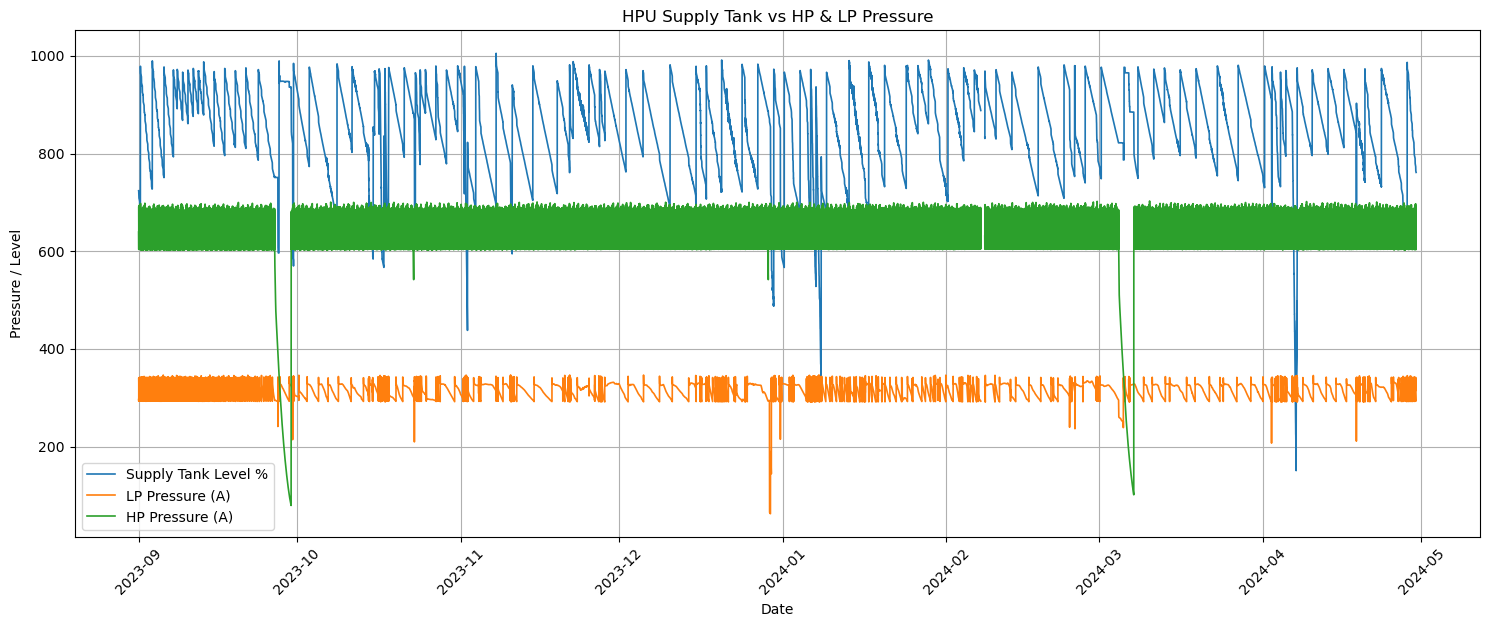

(<Figure size 1500x600 with 1 Axes>,
 [<Axes: title={'center': 'HPU Supply Tank vs HP & LP Pressure'}, xlabel='Date', ylabel='Pressure / Level'>])

In [ ]:
# Quick check of data frame basic plot
plot_hpu_data(
    labeled_df,
    supply_col='HPU_SPLY_LEV_L',
    lp_pressure_col='HPU_LP_A_SPLY',
    hp_pressure_col='HPU_HP_A_SPLY',
    start_date='2023-09-01',
    end_date='2024-04-30'
)

**1. add_low_fluid_consumption_label.** Plot Periods where Supply Consumption is less than 60 litres per day i.e. considered normal/low and stable periods which are shaded in blue

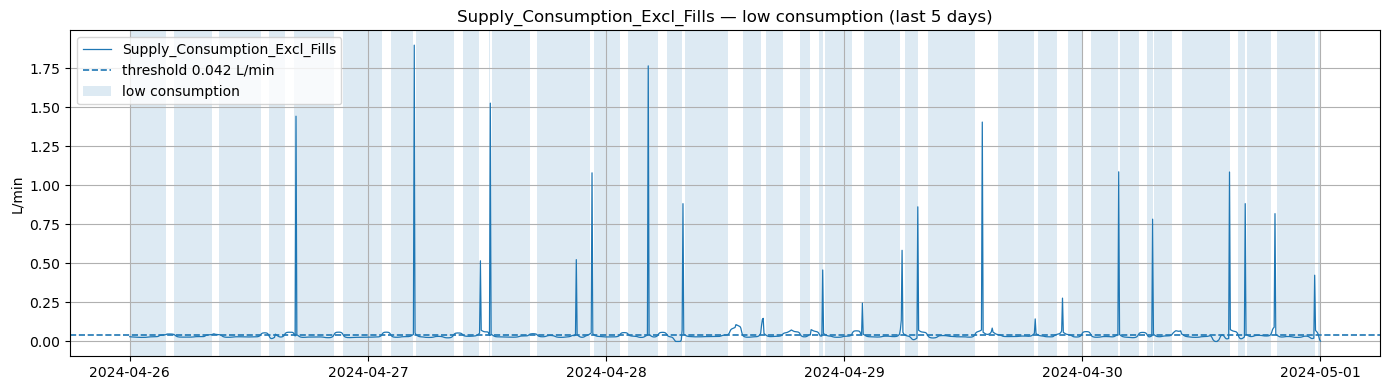

(<Figure size 1400x400 with 1 Axes>,
 [<Axes: title={'center': 'Supply_Consumption_Excl_Fills — low consumption (last 5 days)'}, ylabel='L/min'>])

In [43]:
plot_low_consumption(labeled_df, days=5, threshold_lpm=60/24/60) #60 litres per day

Plot periods where losses are considered high 

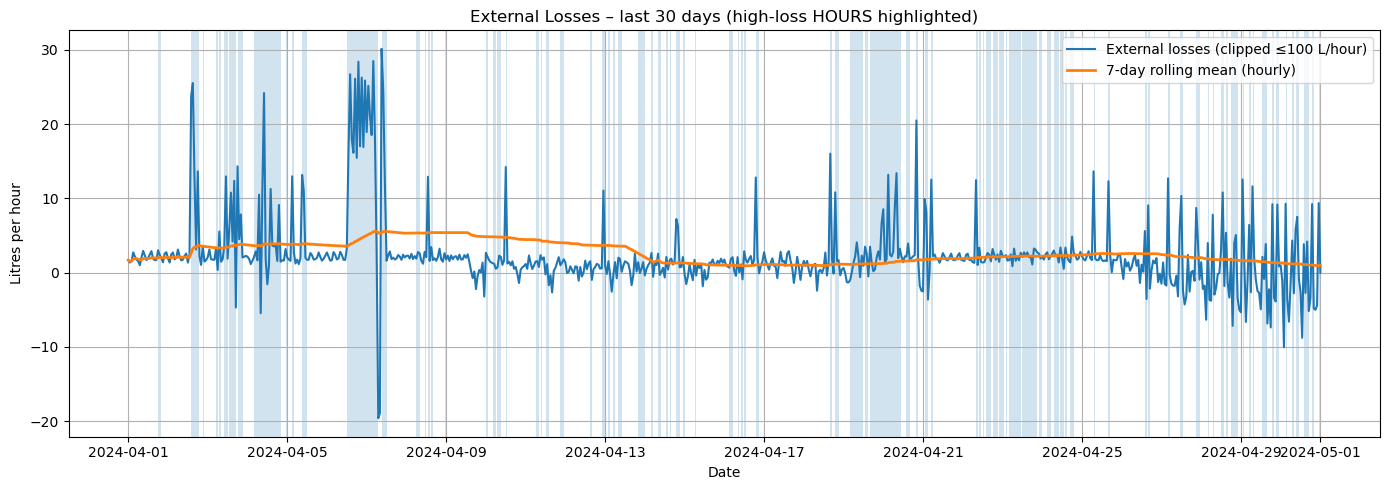

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'External Losses – last 30 days (high-loss HOURS highlighted)'}, xlabel='Date', ylabel='Litres per hour'>])

In [44]:
# --- Hourly version (only the high hours shaded) ---
plot_losses_hourly(labeled_df)

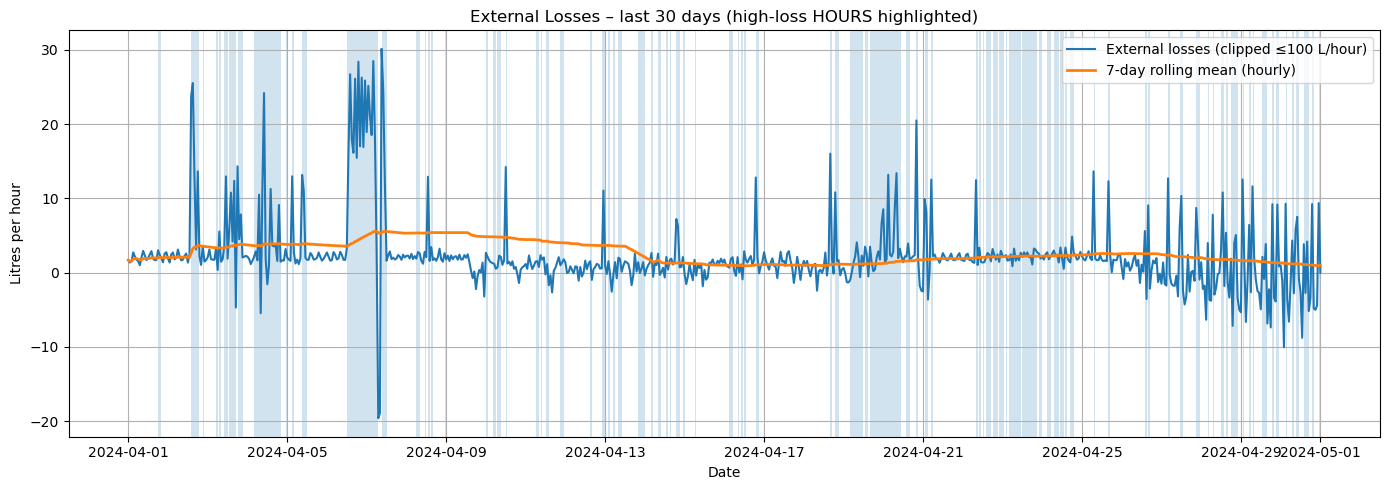

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'External Losses – last 30 days (high-loss HOURS highlighted)'}, xlabel='Date', ylabel='Litres per hour'>])

In [45]:
# --- Hourly version (only the high hours shaded) ---
plot_losses_hourly(labeled_df)

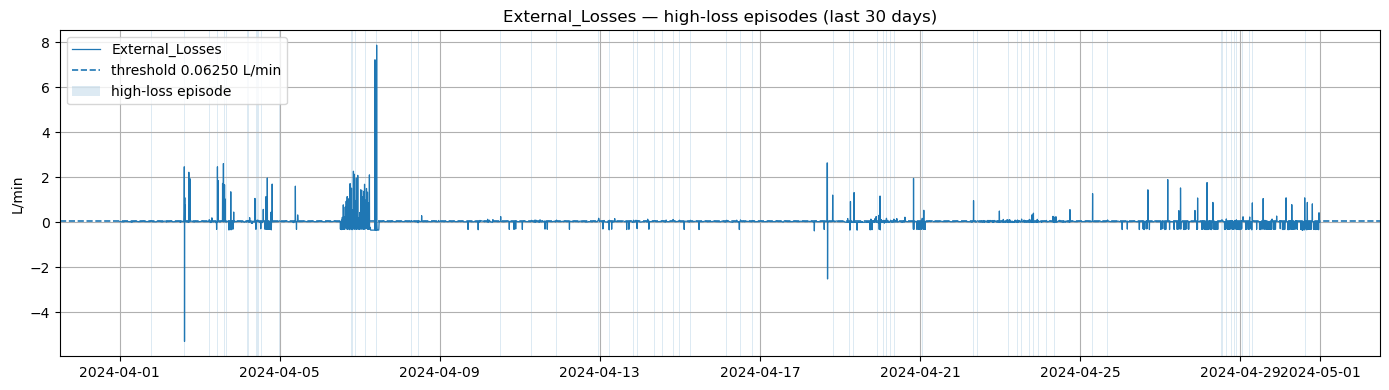

(<Figure size 1400x400 with 1 Axes>,
 [<Axes: title={'center': 'External_Losses — high-loss episodes (last 30 days)'}, ylabel='L/min'>])

In [ ]:

enter_lpm = 90 / 1440 # 90l per day 

plot_external_losses_high(
    labeled_df,
    days=30,
    threshold_lpm=enter_lpm,  # draw reference line at the 90 L/day equivalent
    resample="5T",
    clip_upper=None           # or e.g. 1.0 to tame spikes
)

In [47]:
# Get the external losses metadata
meta_loss = metas["losses_high"]

# Summary
print(f"Events: {meta_loss['n_events']} | % time high: {meta_loss['pct_time_high']:.2f}%")

print(labeled_df['External_Losses'].describe())

Events: 33533 | % time high: 15.61%
count    2.972679e+06
mean     9.276823e-02
std      5.874724e-01
min     -1.800805e+01
25%      2.592481e-02
50%      3.426534e-02
75%      4.925608e-02
max      1.545323e+02
Name: External_Losses, dtype: float64


In [48]:
# Build meta_low from the labelled series
low = labeled_df["is_consumption_low"].astype(bool)

# count contiguous low-consumption episodes
runs = (low != low.shift()).cumsum()
n_events = low.groupby(runs).any().sum()   # number of True-runs

# you used enter_lpm=70/24/60 and exit_lpm=72/24/60 in the pipeline
enter_thr = 60/24/60
exit_thr  = 62/24/60

meta_low = {
    "pct_time_low": float(low.mean() * 100.0),
    "n_events": int(n_events),
    "enter_threshold_L_per_min": enter_thr,
    "exit_threshold_L_per_min": exit_thr,
}

print(f"% time low: {meta_low['pct_time_low']:.2f}% | events: {meta_low['n_events']}")
print("Enter/Exit thresholds (L/min):",
      meta_low['enter_threshold_L_per_min'],
      "/", meta_low['exit_threshold_L_per_min'])


% time low: 68.14% | events: 23983
Enter/Exit thresholds (L/min): 0.041666666666666664 / 0.043055555555555555


**2. label_valve_pcv_operations and label_fcv_operation_from_col.** Plot the PCV and FCV operation data

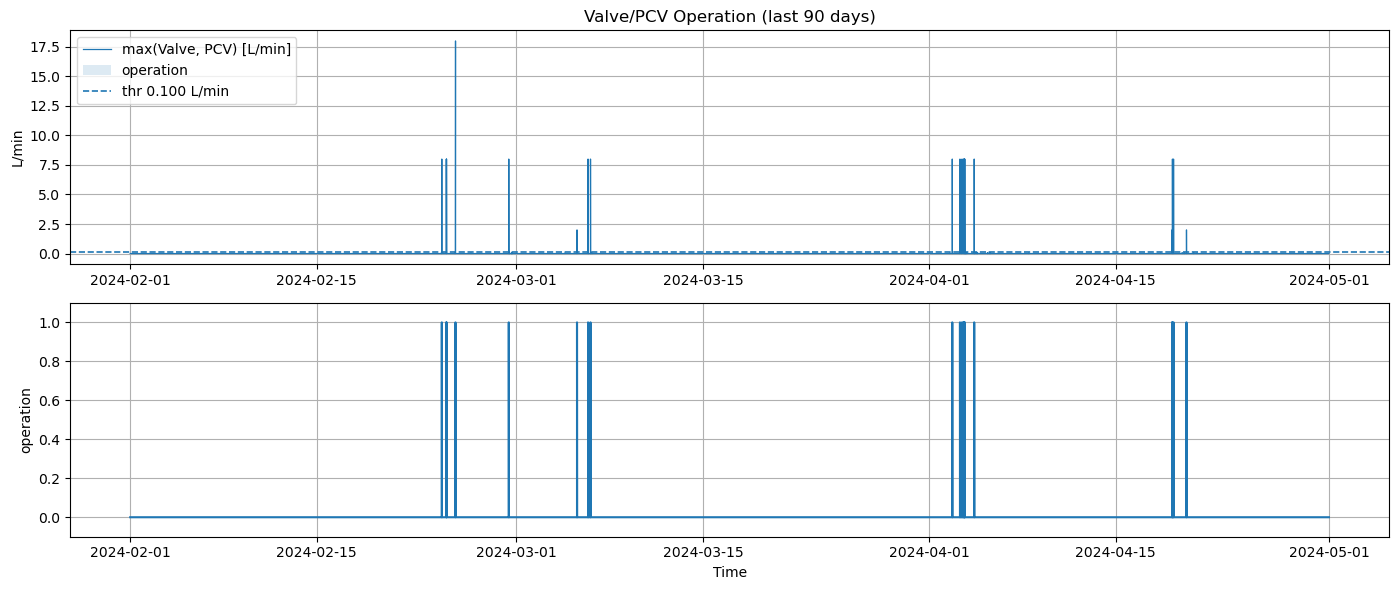

(<Figure size 1400x600 with 2 Axes>,
 [<Axes: title={'center': 'Valve/PCV Operation (last 90 days)'}, ylabel='L/min'>,
  <Axes: xlabel='Time', ylabel='operation'>])

In [49]:
plot_valve_pcv_ops(labeled_df, threshold_lpm=0.1, days=90)

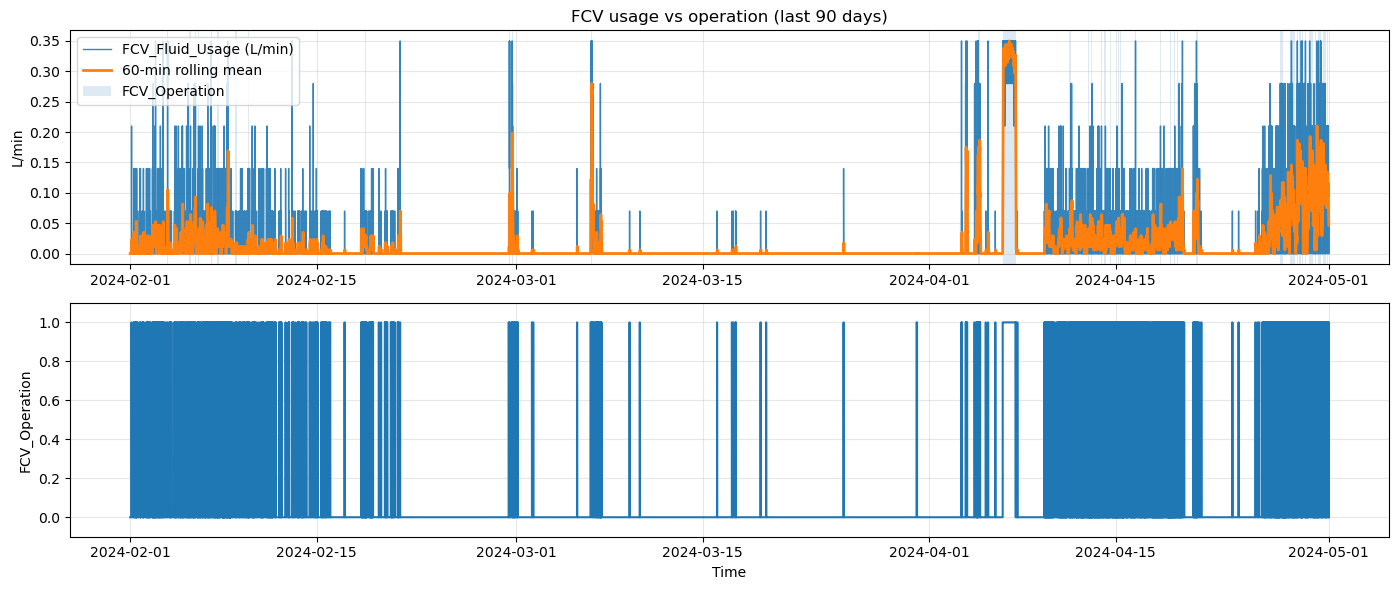

(<Figure size 1400x600 with 2 Axes>,
 [<Axes: title={'center': 'FCV usage vs operation (last 90 days)'}, ylabel='L/min'>,
  <Axes: xlabel='Time', ylabel='FCV_Operation'>])

In [50]:
plot_fcv_usage_vs_operation_line(
    labeled_df,
    usage_col="FCV_Fluid_Usage",
    op_col="FCV_Operation",
    days_to_show=90,
    resample_rule="5T",      # smoother line; set to None for raw cadence
    rolling_minutes=60       # optional: add 1-hour rolling mean
)


In [ ]:
# get the FCV metadata block
fcv_meta = metas["fcv_ops"]
print(f"FCV on-time: {fcv_meta['pct_on']:.2f}% | events: {fcv_meta['n_events']}")
fcv_meta['runs'].head()

FCV on-time: 6.43% | events: 91289


,start,end,minutes
0,2018-10-12 10:45:00,2018-10-12 10:53:00,9
1,2018-10-12 15:22:00,2018-10-12 15:28:00,7
2,2018-10-19 17:09:00,2018-10-19 17:16:00,8
3,2018-10-19 17:27:00,2018-10-19 17:35:00,9
4,2018-10-19 18:03:00,2018-10-19 18:05:00,3


 **3. label_tank_fills.**  Display periods where the tank is being filled i.e. tank level increasing

In [52]:
# Extract the tank_fills section
fills_meta = metas["tank_fills"]

# Summary info
print(f"fills: {fills_meta['n_events']} | % time filling: {fills_meta['pct_time_fill']:.2f}%")

# If runs is a DataFrame
if isinstance(fills_meta["runs"], pd.DataFrame):
    print(fills_meta["runs"].head())

# If it's a list of dicts, convert it
elif isinstance(fills_meta["runs"], list):
    import pandas as pd
    df_runs = pd.DataFrame(fills_meta["runs"])
    print(df_runs.head())

fills: 1496 | % time filling: 6.11%
                start                 end  minutes
0 2018-09-05 10:52:00 2018-09-05 12:02:00       71
1 2018-09-06 09:39:00 2018-09-06 11:41:00      123
2 2018-09-07 10:51:00 2018-09-07 12:53:00      123
3 2018-09-08 12:41:00 2018-09-08 14:44:00      124
4 2018-09-09 16:04:00 2018-09-09 18:06:00      123


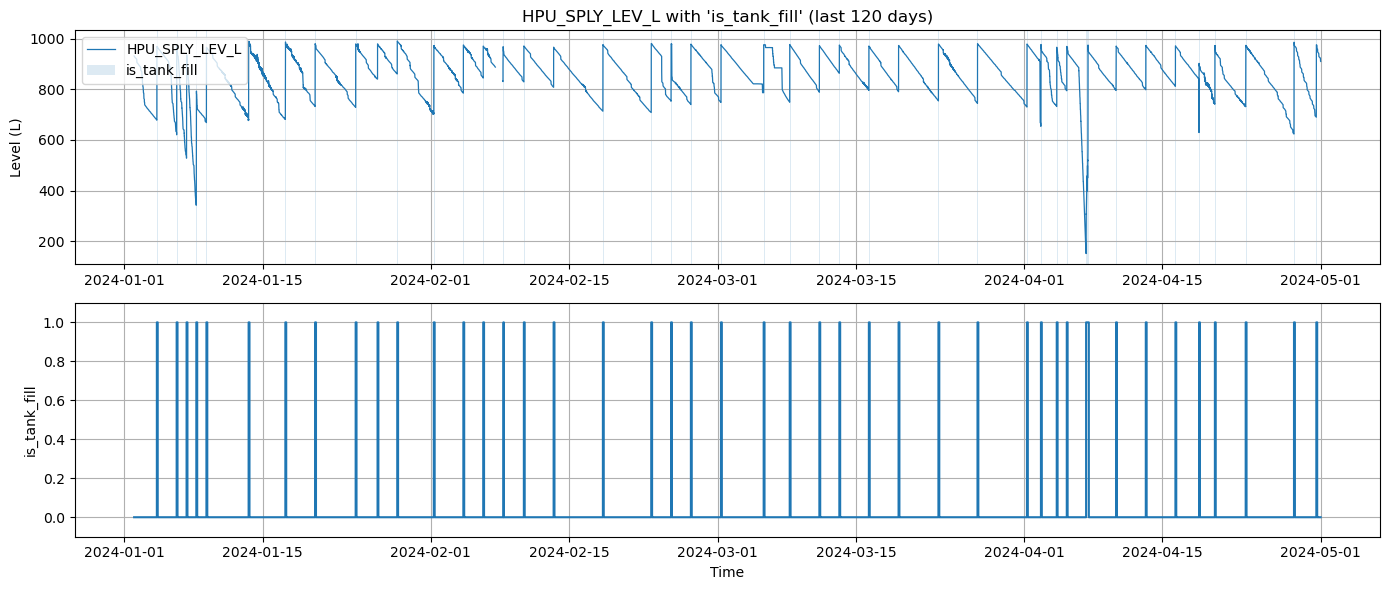

fills: 1496 | % time filling: 6.11%
                start                 end  minutes
0 2018-09-05 10:52:00 2018-09-05 12:02:00       71
1 2018-09-06 09:39:00 2018-09-06 11:41:00      123
2 2018-09-07 10:51:00 2018-09-07 12:53:00      123
3 2018-09-08 12:41:00 2018-09-08 14:44:00      124
4 2018-09-09 16:04:00 2018-09-09 18:06:00      123


In [53]:
    
plot_level_vs_fill_label(
labeled_df,                   # or df_recnt
level_col='HPU_SPLY_LEV_L',
label_col='is_tank_fill',
days_to_show=120
)

# Extract the tank_fills section
fills_meta = metas["tank_fills"]

# Summary info
print(f"fills: {fills_meta['n_events']} | % time filling: {fills_meta['pct_time_fill']:.2f}%")

# If runs is a DataFrame
if isinstance(fills_meta["runs"], pd.DataFrame):
    print(fills_meta["runs"].head())

# If it's a list of dicts, convert it
elif isinstance(fills_meta["runs"], list):
    import pandas as pd
    df_runs = pd.DataFrame(fills_meta["runs"])
    print(df_runs.head())

**4. detect_umbilical_charge_events.** Plot periods where the system is marked as pressurising ie..e charging the system where there will be high fluid volume use

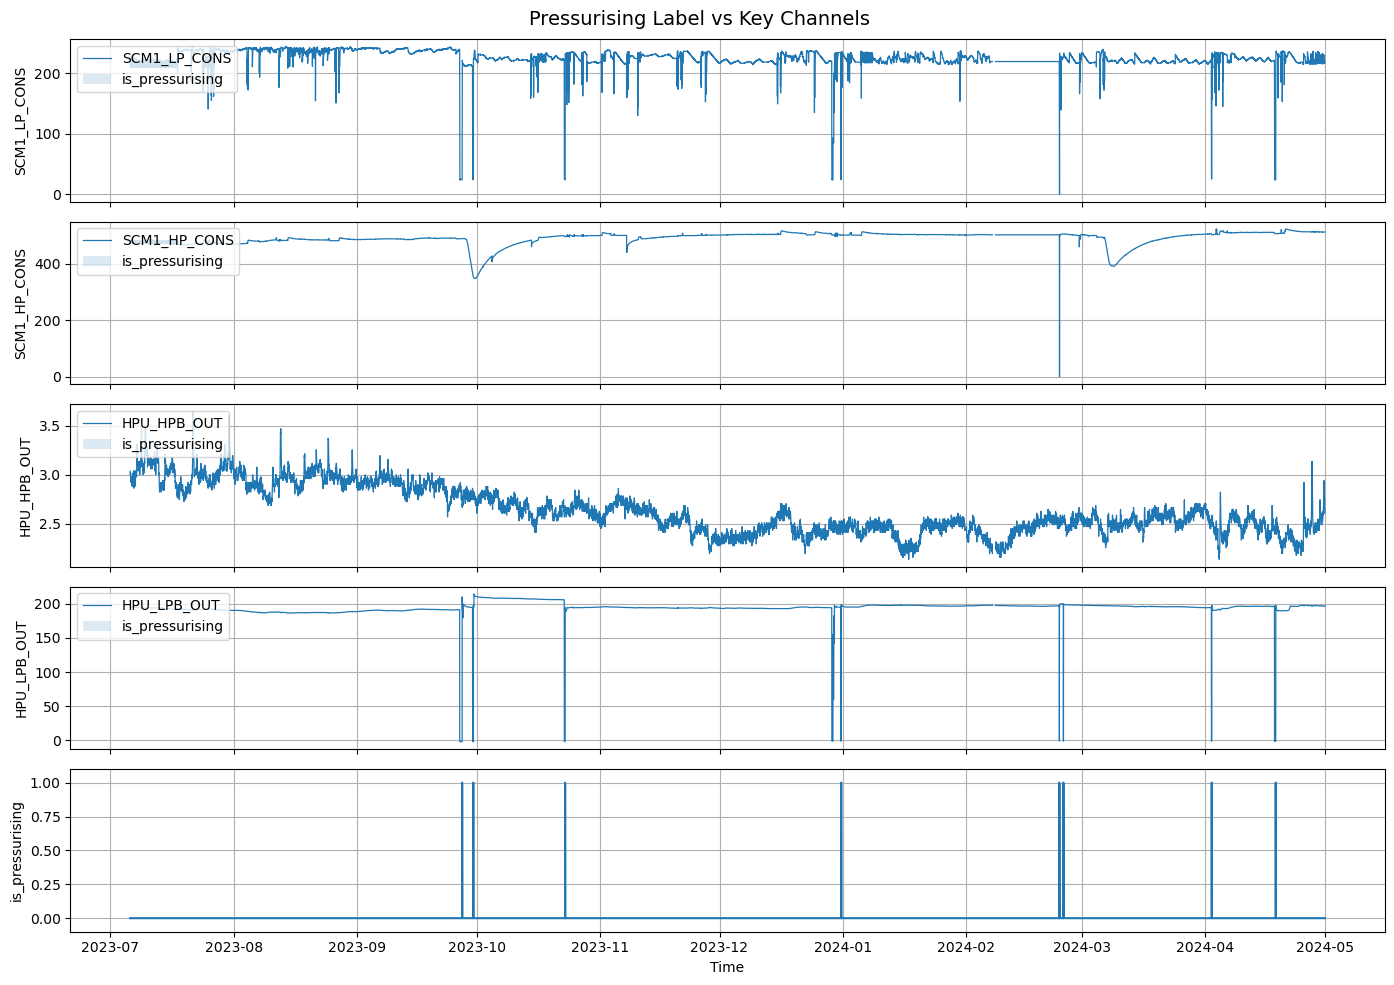

In [54]:

channels_to_plot = ['SCM1_LP_CONS', 'SCM1_HP_CONS', 'HPU_HPB_OUT', 'HPU_LPB_OUT']

plot_pressurising_vs_channels(
    labeled_df,
    channels=channels_to_plot,
    label_col='is_pressurising',
    days_to_show=300,
    title="Pressurising Label vs Key Channels"
)

**5. label_high_pressure.**  Display where there are High System pressures in order to alert operator to integrity risk and also Low system pressures to inform operator of a risk to production

In [55]:
cols = ["SCM1_LP_CONS", "SCM1_HP_CONS"]

# full descriptive stats
print(labeled_df[cols].describe())

# if you only want min & max
print("LP min:", labeled_df["SCM1_LP_CONS"].min(), "LP max:", labeled_df["SCM1_LP_CONS"].max())
print("HP min:", labeled_df["SCM1_HP_CONS"].min(), "HP max:", labeled_df["SCM1_HP_CONS"].max())

       SCM1_LP_CONS  SCM1_HP_CONS
count  2.943890e+06  2.943859e+06
mean   2.222046e+02  5.140102e+02
std    2.673118e+01  3.706736e+01
min    0.000000e+00  0.000000e+00
25%    2.210000e+02  5.030000e+02
50%    2.253913e+02  5.240000e+02
75%    2.300000e+02  5.320000e+02
max    2.619973e+02  5.520000e+02
LP min: 0.0 LP max: 261.9973449707031
HP min: 0.0 HP max: 552.0


[LP]  threshold ≥ 230 | minutes evaluated: 287,941 | accuracy: 82.09%  (TP=0, TN=236357, FP=0, FN=51584)
[HP]  threshold ≥ 535 | minutes evaluated: 287,941 | accuracy: 100.00%  (TP=0, TN=287941, FP=0, FN=0)


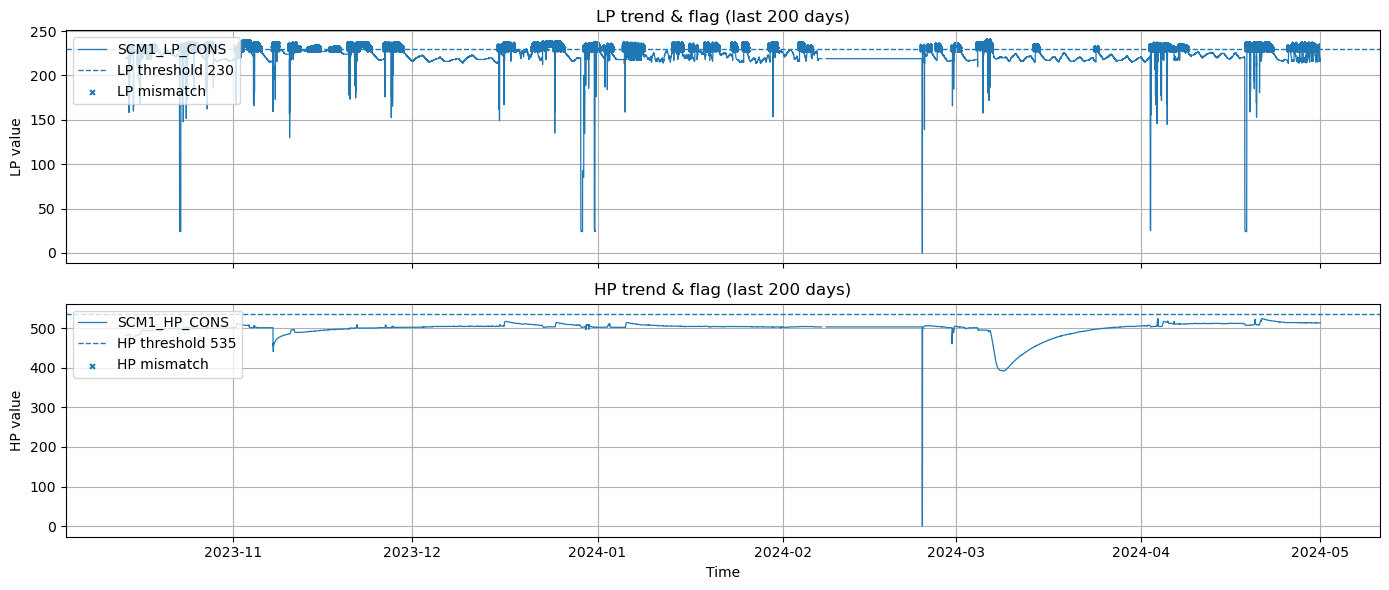

In [56]:
df_eval, lp_metrics, hp_metrics = evaluate_pressure_flags(
    labeled_df,
    lp_col='SCM1_LP_CONS', hp_col='SCM1_HP_CONS',
    lp_thr=230, hp_thr=535,
    lp_flag_col='is_lp_high', hp_flag_col='is_hp_high',
    days=200, make_plots=True
)

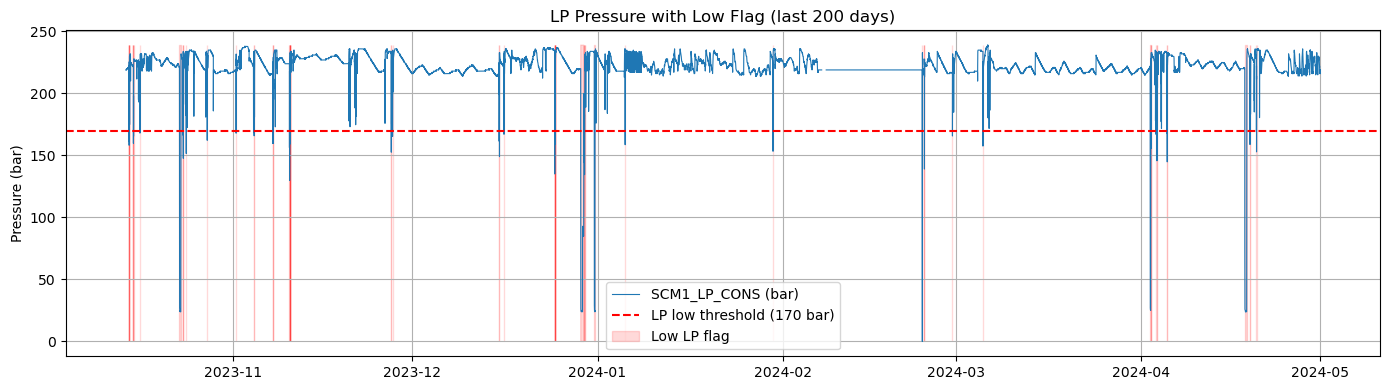

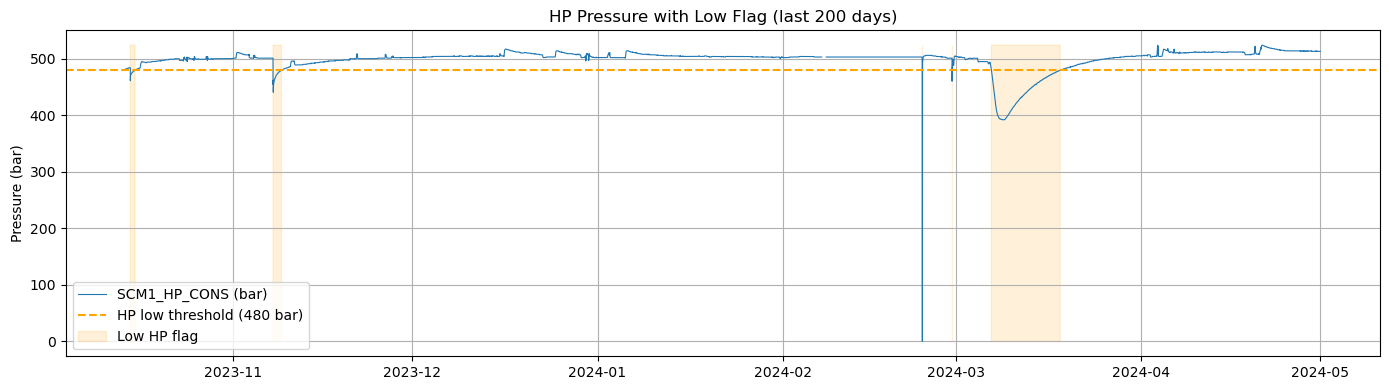

In [57]:
plot_lp_hp_flags(labeled_df, days_to_show=200)

Determine periods where there is a loss of system redundancy i.e. no dual LP or dual HP supplies

In [58]:
mask_nr = labeled_df["is_no_redundancy"]

print(f"No redundancy % of time: {mask_nr.mean() * 100:.2f}%")

No redundancy % of time: 66.94%


**6. add_pump_states**  Display Pump status , i..e 0/1/2 for normal, elevated / high frequency 

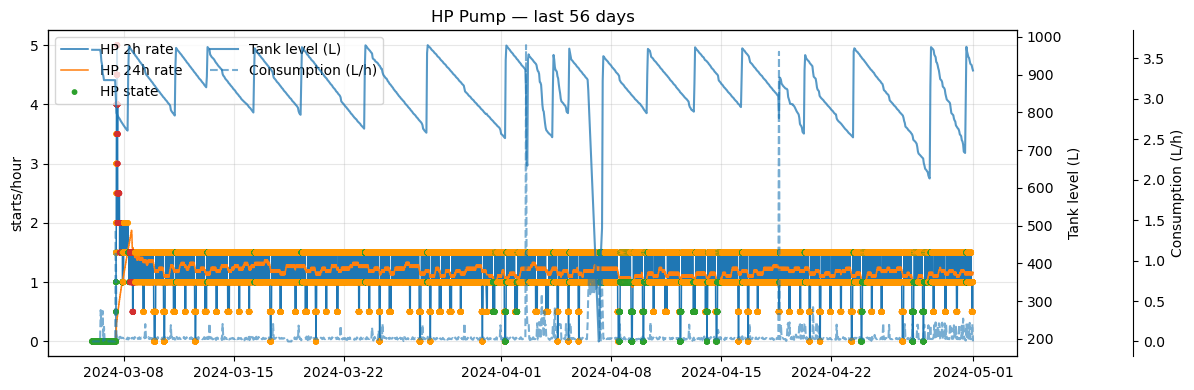

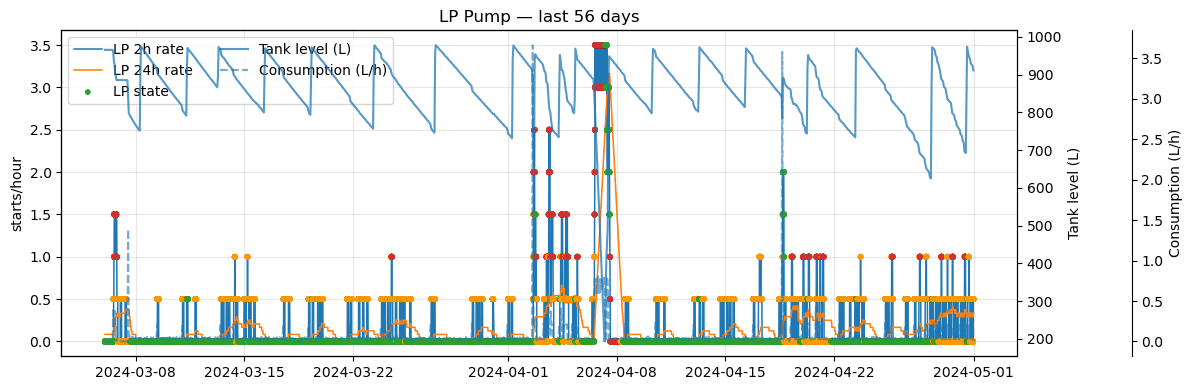

In [59]:
plot_last_weeks_with_overlays(
    labeled_df,    # or df_recnt
    days=56,
    level_col="HPU_SPLY_LEV_L",
    cons_col="Supply_Consumption_Excl_Fills",
    #thr=thresholds,                  # pass thresholds to draw guides (optional)
    show_thresholds=True,
    shade_24h_high=True
)

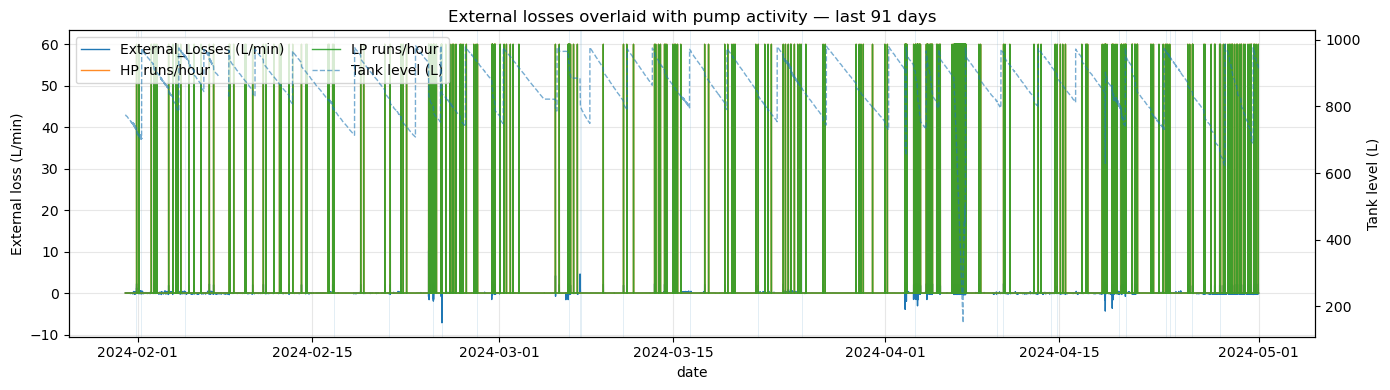

% time high losses (window): 3.95%
% of time high losses while HP running: 55.36%
% of time high losses while LP running: 55.36%


In [60]:
# ----- call it (example with your column names) -----
overlay_external_losses_with_pumps(
    labeled_df,
    loss_col='External_Losses',
    high_mask_col='is_losses_high',
    hp_cum_col='Cum_LP_Pump_A_Run_Count',
    lp_cum_col='Cum_LP_Pump_A_Run_Count',
    level_col='HPU_SPLY_LEV_L',
    window_days=91,
    base_freq='1T',          # change to '5T' or '1H' if your data is coarser
    smooth_minutes=5
)


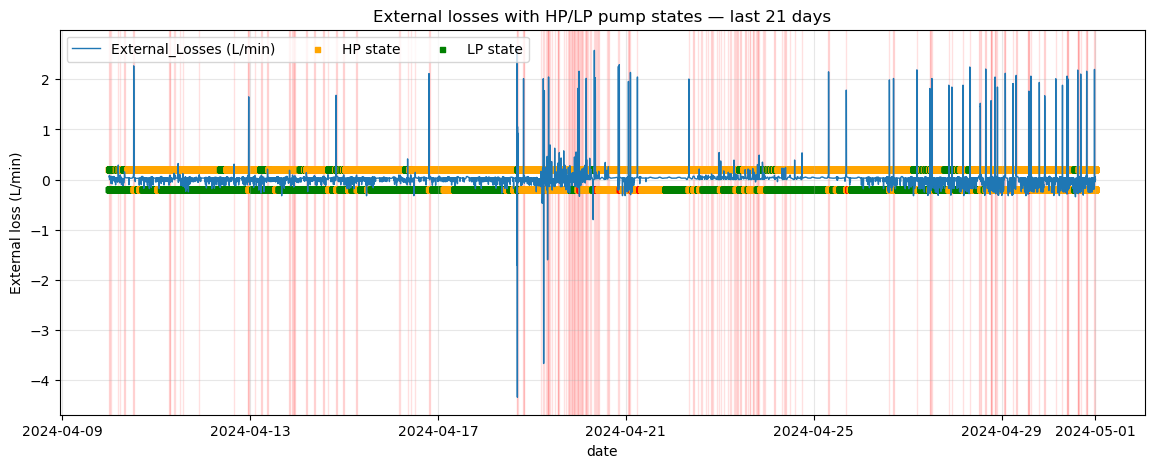

In [61]:
# 0) Ensure datetime index & sort once
labeled_df.index = pd.to_datetime(labeled_df.index, errors="coerce")
labeled_df.sort_index(inplace=True)

# 1) Map pump state integers -> readable labels
#    (change the mapping if your codes differ)
state_map = {0: "off", 1: "steady", 2: "elevated", 3: "high"}

hp_state = labeled_df["HP_pump_state"].map(state_map)
lp_state = labeled_df["LP_pump_state"].map(state_map)

# 2) Make sure they’re aligned to the full time index (ffill handles event-style changes)
hp_state = hp_state.reindex(labeled_df.index).ffill()
lp_state = lp_state.reindex(labeled_df.index).ffill()

overlay_losses_with_pump_states(
    labeled_df,
    loss_col="External_Losses",
    high_mask_col="is_losses_high",
    hp_state=hp_state,
    lp_state=lp_state,
    window_days=21,
    smooth_minutes=5
)

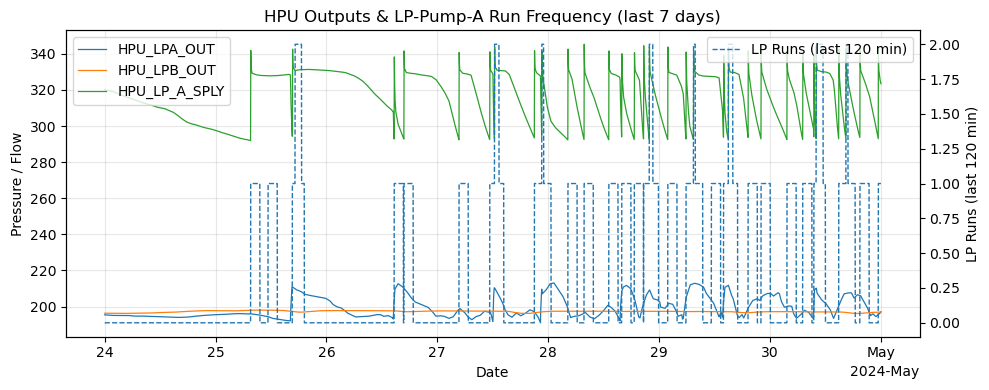

In [62]:
df_last = plot_hpu_outputs_with_lp_runs(labeled_df, window_days=7)

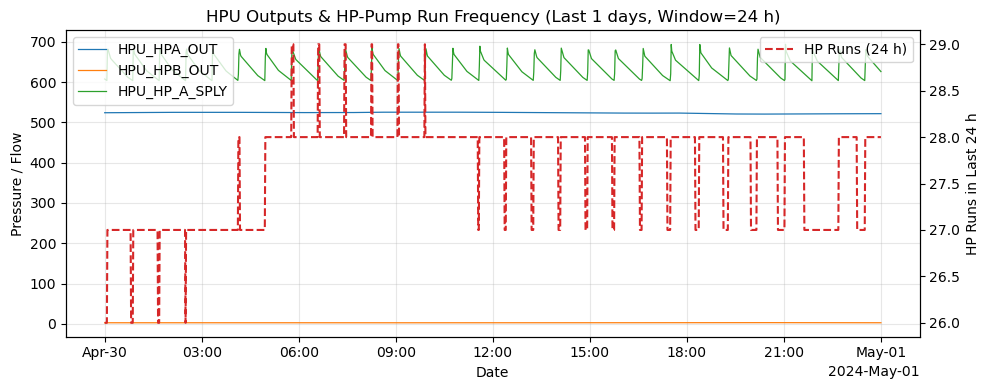

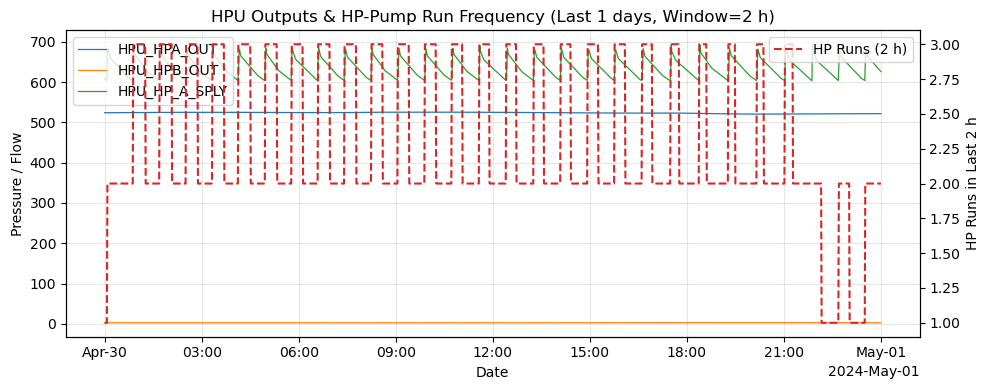

In [63]:
df_last = plot_hp_runs(labeled_df)

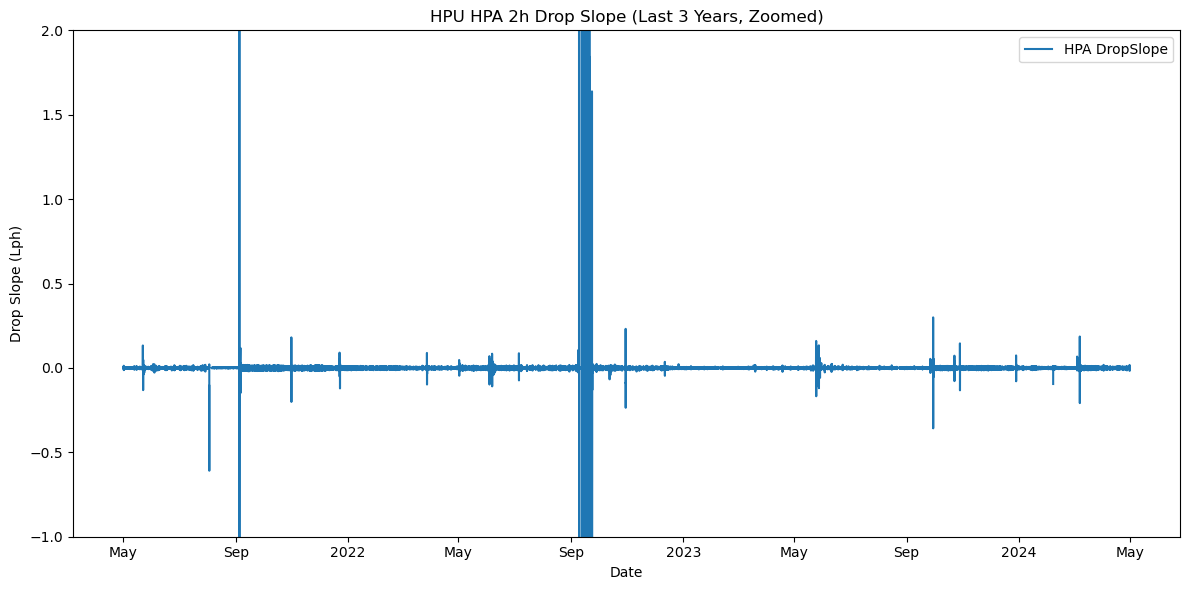

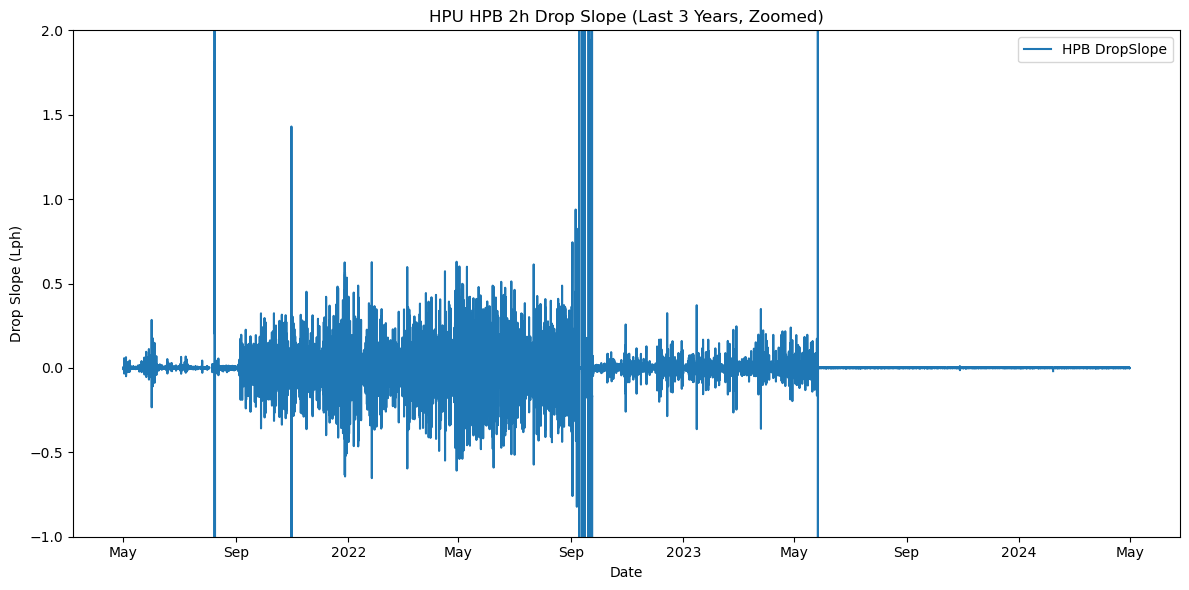

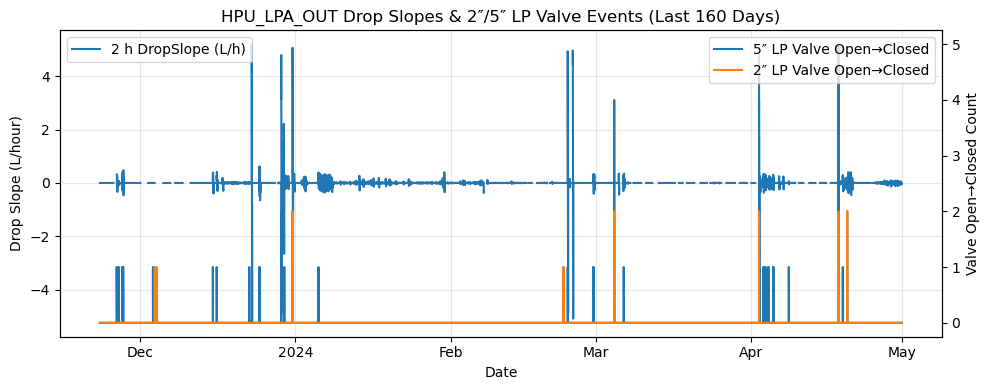

In [64]:
# 1) HP 2h DropSlopes (like your two plots; last 3 years, y-zoom -1..2)
plot_hp_2h_dropslopes(labeled_df, years=3, y_limits=(-1, 2), separate_figures=True)

# 2) LPA 2h DropSlope + valve events (last 160 days to match your slice)
plot_lpa_dropslopes_with_valves(labeled_df, days=160)

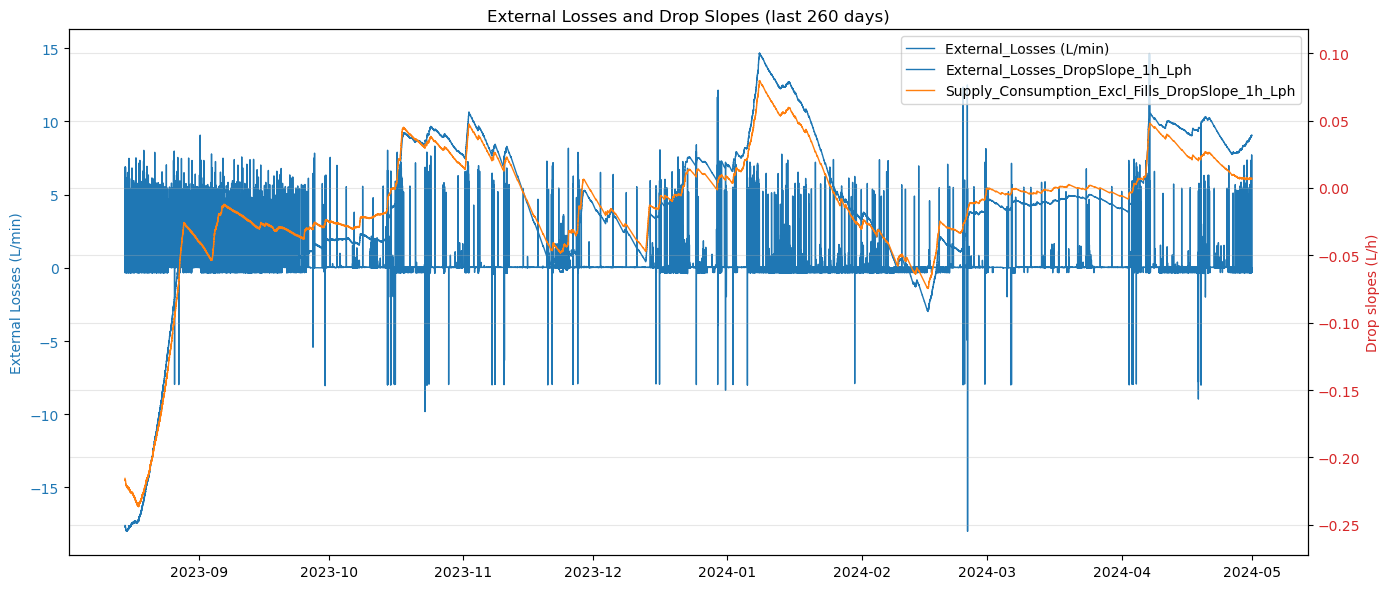

In [65]:
plot_drop_slopes(labeled_df, days=260)


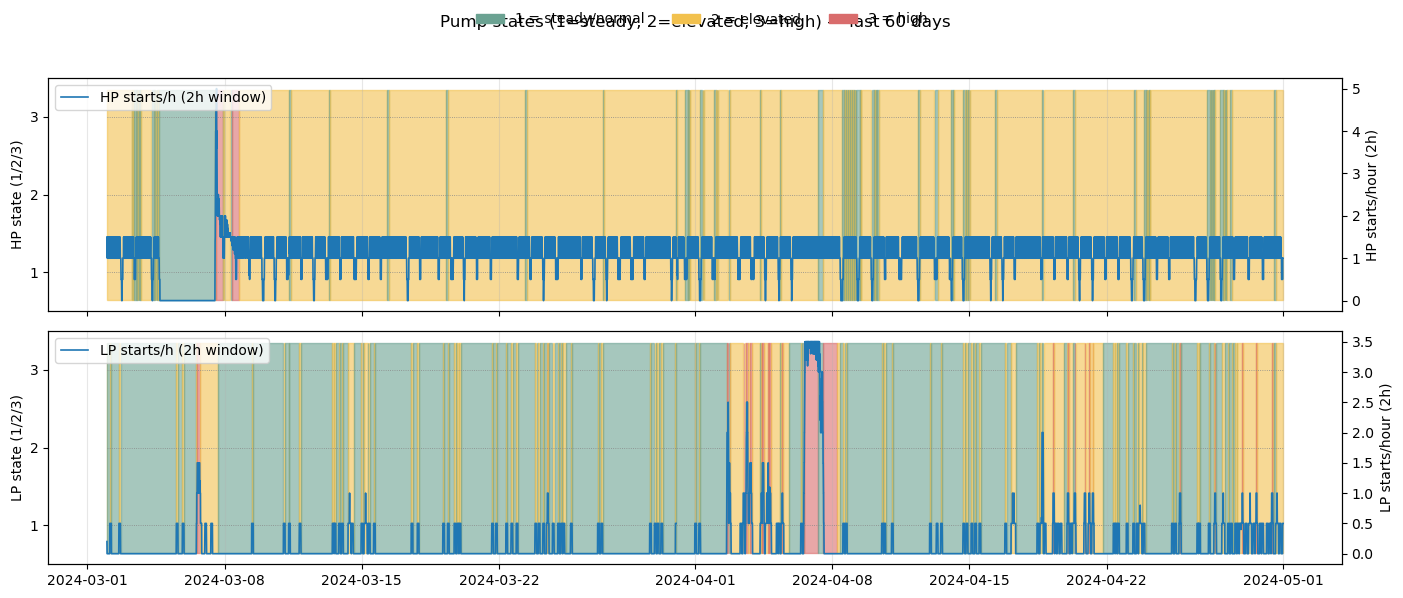

In [66]:
plot_pump_states_timeline(
    df=labeled_df,
    hp_state_col="HP_pump_state",
    lp_state_col="LP_pump_state",
    hp_rate2_col="HP_pump_rate_2h",   # omit or set None if you don't want rates
    lp_rate2_col="LP_pump_rate_2h",
    days=60,
    resample="5T"
)

##### 7. Final DataFrame Clean & Valve Split — Summary

The called Function drops unused columns, **splitting valve state columns into a separate table, standardising names, deal with failed valve position indicators and encodes valve status


2. **Drops unused/duplicate columns** (HPU level duplicates, extra SCM channels, raw PCV/transition counters, cumulatives/intermediates, selected slopes/EWM, etc.).
3. **Splits valve position/state columns** (e.g., `P1_*`, `P2_*`, `P3_*`, `I1/2_*`, `SCM*_COV`, `Man_CI`, `MPMV_Inlet`) into a separate `otter_valve_positions_df`.
4. **Brings key HPU level columns to the front** of the main DataFrame: `HPU_SPLY_LEV_L`, `HPU_RET_LEV_L`, and their smoothed versions when present.
5. **Renames slope and MA/EWM fields** to consistent names (e.g., `Slope_2H_Lph` → `Supply_Slope_2H_Lph`, `EWM_7d` → `External_Loss_EWM_7d`).
6. **Coerces numeric types** for retained FCV fields (`FCV_CPI`, `FCV_Fluid_Usage`).
7. **Encodes valve states** in the split DataFrame: `OPEN=1`, `CLOSED=0`, faults/unknowns = `-1`; then applies **overrides** (sets `-1 → 1` for specific valves: `P3_PDV`, `I2_AMV`, `P3_PWV`, `P3_AMV`).
8. **Reorders pump metrics** to appear just before `is_consumption_low` when present (`HP_pump_rate_2h`, `HP_pump_state`, `LP_pump_rate_2h`, `LP_pump_state`).
9. **Validates required columns** (`is_losses_high`, `is_consumption_low`), then derives:
   - `is_steady_state` = 1 when external losses are **not high**.
   - `is_steady_state_strict` = 1 when **consumption is low**.



In [69]:
df_clean, otter_valve_positions_df = clean_dataframe_and_split_valves(labeled_df)

steady_state = 84.4%
steady_state_strict = 68.1%


In [ ]:
# Check the final dataframe and all its columns . 
# Show first few rows
print("=== Head of dataframe ===")
print(df_clean.head(), "\n")

# Shape (rows x columns)
print("=== Shape ===")
print(df_clean.shape, "\n")

# List of columns
print("=== Columns ===")
print(df_clean.columns.tolist(), "\n")

# Data types and non-null counts
print("=== Info ===")
print(df_clean.info(), "\n")

# Basic stats for numeric columns
print("=== Describe ===")
print(df_clean.describe().T)

print("Valve positions df:", otter_valve_positions_df.shape)
print(otter_valve_positions_df.columns[:28])

=== Head of dataframe ===
                     HPU_SPLY_LEV_L  HPU_RET_LEV_L  HPU_SPLY_LEV_L_Smooth  \
2018-09-05 09:22:00      428.141365     411.271374             428.900272   
2018-09-05 09:23:00      428.104401     411.247410             428.864231   
2018-09-05 09:24:00      428.067436     411.223412             428.828909   
2018-09-05 09:25:00      428.030472     411.199413             428.794453   
2018-09-05 09:26:00      427.993469     411.175449             428.761030   

                     HPU_RET_LEV_L_Smooth  HPU_LP_A_SPLY  HPU_HP_A_SPLY  \
2018-09-05 09:22:00            411.260792     314.771545     628.917053   
2018-09-05 09:23:00            411.238281     314.615387     627.680542   
2018-09-05 09:24:00            411.215445     314.459229     626.444031   
2018-09-05 09:25:00            411.192308     314.303040     625.207520   
2018-09-05 09:26:00            411.168888     314.146881     623.970947   

                     HPU_LPA_OUT  HPU_LPB_OUT  HPU_HPA_OUT  

In [71]:
print(df_clean[["is_steady_state","is_steady_state_strict"]].mean())

is_steady_state           0.843886
is_steady_state_strict    0.681422
dtype: float64
